# Imports

In [9]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='retina'

from quantum_electron.electron_counter import FullModel
from quantum_electron.schrodinger_solver import find_minimum_location, make_potential
from quantum_electron.utils import r2xy, xy2r
from zeroheliumkit.fem.fieldreader import FreeFemResultParser, FieldAnalyzer
from zeroheliumkit.src.settings import *
from zeroheliumkit.src.importing import Reader_GDS,Reader_DXF,Reader_Pickle # type: ignore
from zeroheliumkit import Structure, Rectangle, GeomCollection # type: ignore
from zeroheliumkit.src.plotting import ColorHandler



# Device and FEM Results

In [49]:
ffparser = FreeFemResultParser("dump/metadata.yaml")

                result1
--------------  -------------
Quantity        phi
Plane           xy
X Min           -10
X Max           10
X Num           201
Y Min           1950
Y Max           2125
Y Num           201
Slices          1
Slice Values    [0.96]
Curved Surface  False
Schema          (1, 201, 201)
Control Electrodes: ['Barrier', 'ThinFilm', 'IDC+', 'IDC-', 'Top']


In [50]:
ffparser.get_capacitance_matrix()

[[-11705.6, 4642.75, 670.661, 3322.04, 3692.42],
 [4327.06, -6496.06, 346.654, 1063.03, 170.676],
 [724.148, 436.749, -16692.1, 6208.42, 10582.4],
 [3436.31, 1309.7, 6191.03, -19665.6, 10779.0],
 [3218.08, 106.836, 9483.79, 9072.15, -25224.5]]

TransferDevice_IDCs.gds // Layers in cell 'toplevel': [1, 2, 3]


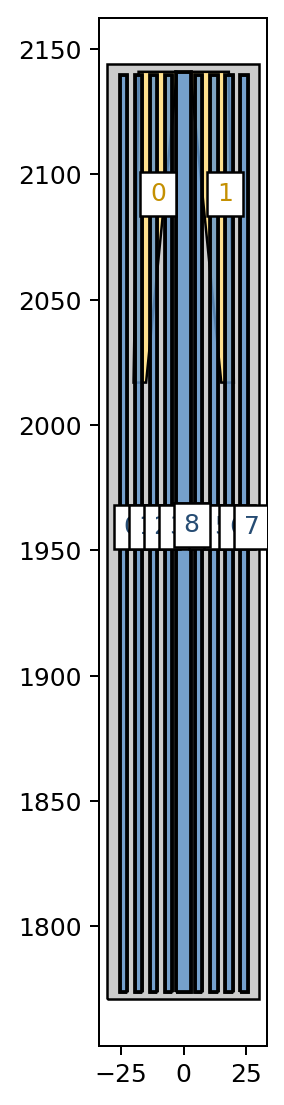

In [51]:
# Read File
file = Reader_GDS('TransferDevice_IDCs.gds')
device = GeomCollection(file.geometries)

# Rename Layers
device.rename('L1','bottom')
device.rename('L2','top')
device.rename('L3','wafer')

device.colors = ColorHandler({
    "wafer": GRAY,
    "top": YELLOW2,
    "bottom": (BLUE, 0.85)
})

device.quickplot(size='large',show_idx=True)
plt.show()
ffparser.load_data("dump/results/", "result1")
cc1 = ffparser.get_coupling_constants(slice_value=0.96, round_with_decimals=6)
ph = FieldAnalyzer(cc1)

# Definitions 

In [52]:
hbar = 1.05457182e-34       # [J*s]             plank's constant          
epsilon_0 = 8.854e-12       # [F/m]             vacuum permittivity
mu_0 = 1.25663706e-6        # [N/A^2]   vacuum permeability
epsilon_He = 1.057          # [1]               dielectric constant of helium
qe = 1.602e-19              # [Coulombs]        electron charge
me = 9.1093837e-31          # [kg]              electron mass
g = 9.81                    # [m/s^2]           gravity constant
alpha = 3.58e-4             # [N/p]             surface tension
rho = 146                   # [kg/m^3]          helium density
kb = 1.3806e-23             # [J/K]             boltzman constant
speedoflight = 299792458.0  # [m/s]             speed of light

GHz = 1e9
MHz = 1e6
kHz = 1e3

cm = 1e-2
mm = 1e-3
um = 1e-6
nm = 1e-9

options = {"include_screening" : False, # Include screening of electron-electron interactions due to thin film.
           "screening_length" : 0.6e-6, # Typically helium thickness.
           "potential_smoothing" : 1e-1, # Numerical smoothing of the splines (gets rid of some noise, can introduce artifacts)
           "remove_unbound_electrons" : True, # Removes electrons if they shot outside the solution box.
           "remove_bounds" : (-1.0e-6, 1.0e-6), # Sets which electrons should be removed if above is True.
           "trap_annealing_steps" : [0.5] * 0, # List of annealing temperatures, length determines the number of steps
           "max_x_displacement" : 0.1e-6, # Maximum x-displacement of solved electron positions during annealing.
           "max_y_displacement" : 0.1e-6} # Maximum y-displacement of solved electron positions during annealing.

# Coupling Constants

TypeError: cannot unpack non-iterable NoneType object

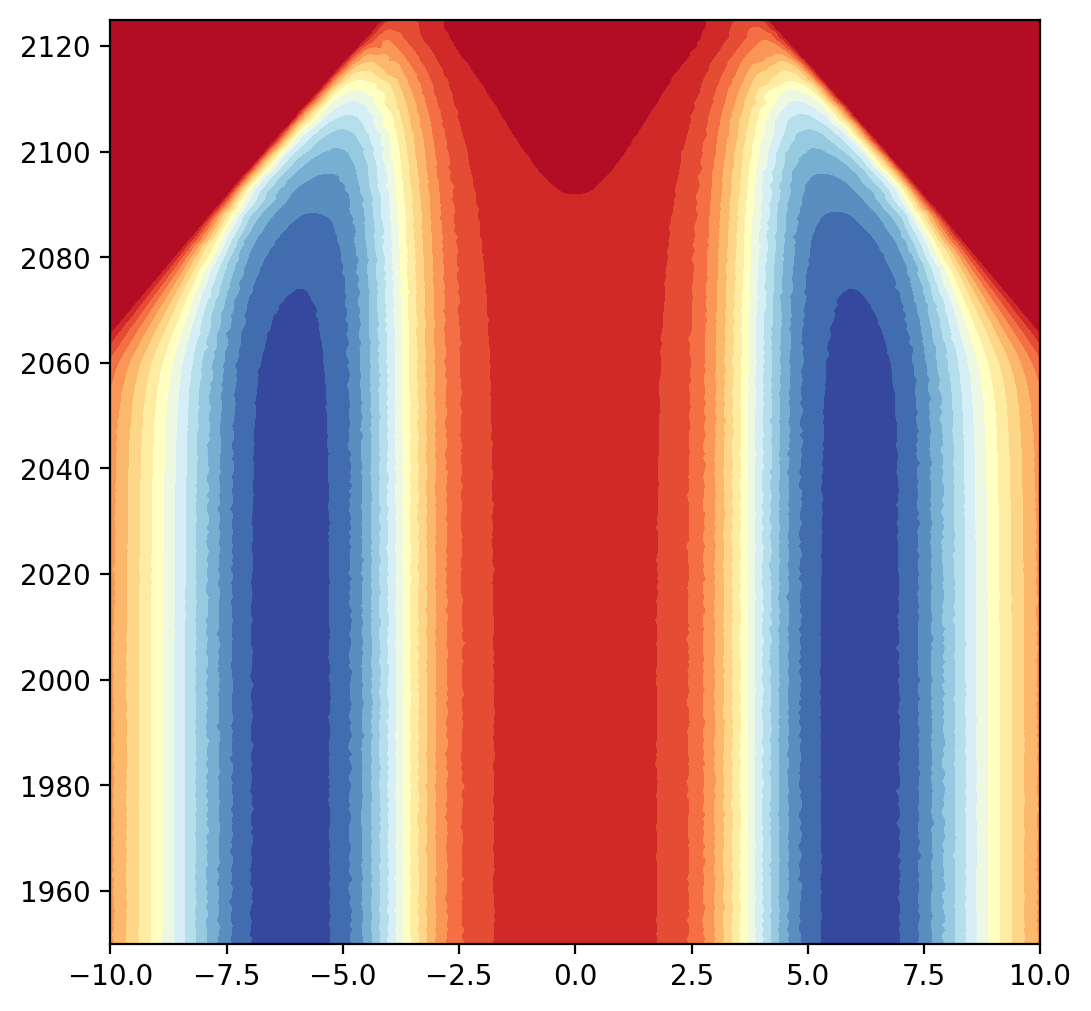

In [59]:
# By setting the voltage of each gate to 1, we can plot the coupling constants
voltages = {
    'Barrier':0,
    'IDC-':0,
    'IDC+':0,
    'ThinFilm':0,
    'Top':0,
}
for k,v in voltages.items():
    voltages[k] = 1
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    ph.set_voltages(voltages)
    x,y,z = ph.plot2D_data(ax=ax, zero_line=False, cmap='RdYlBu')
    #x,y,z = ph.plot_potential_1D(ph.dot, voltages, zlevel_key=1.6, zero_line=False, cmap='RdYlBu')
    plt.pcolormesh(x,y,z.T,alpha = 1)
    plt.clim(0,1)
    plt.colorbar()
    plt.xlim(-15,10)
    plt.ylim(-5,55)
    plt.title(k)
    plt.show()

    voltages[k] = 0

# DC Voltage Config

### Look at a random voltage config

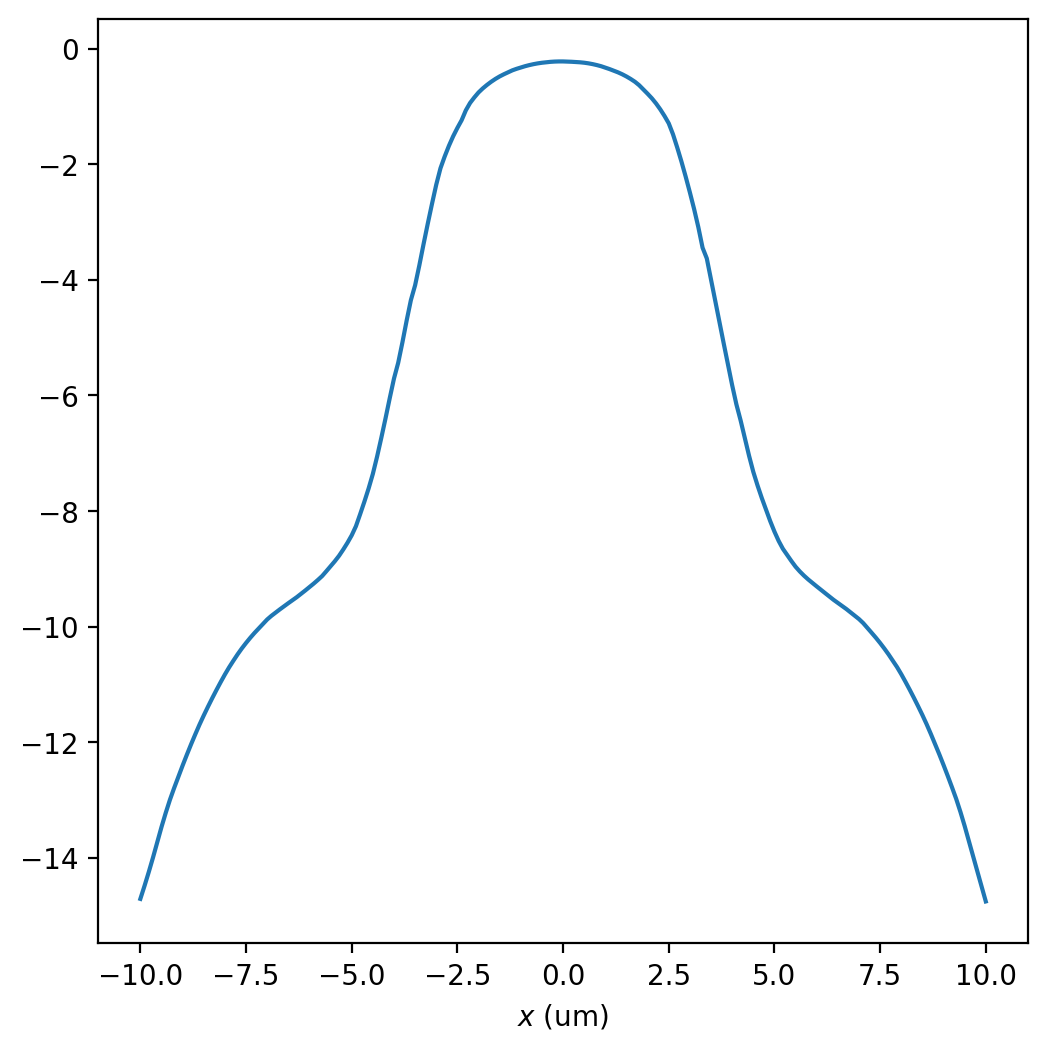

In [58]:
voltages = {
    'Barrier':-10,
    'IDC-':-20,
    'IDC+':20,
    'ThinFilm':1,
    'Top':-1,
}
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

ph.set_voltages(voltages)
ph.plot1D_data(slice = ('x',0),ax=ax)
#ph.plot2D_data(ax=ax, zero_line=False, cmap='RdYlBu')
# device.top.plot(ax=ax, edgecolor=BLACK)

# ax.set_aspect("equal")

plt.show()

In [24]:
voltages = {
    'Barrier':1,
    'IDC-':0,
    'IDC+':0,
    'ThinFilm':0,
    'Top':0,
}


x,y,z = ph.potential(p,voltages)

# Take a line cut along the middle and add a dashed line at the top ground plane potential
xC = int(len(x)/2)
plt.figure(figsize=(10,5))
plt.title('Y Cut')
plt.hlines(-voltages['Top'],y.min(),y.max(),'k','--')
plt.plot(y,-z[xC,:])



AttributeError: 'zeroheliumkit.fem.fieldreader.FieldAnalyzer' object has no attribute 'potential'

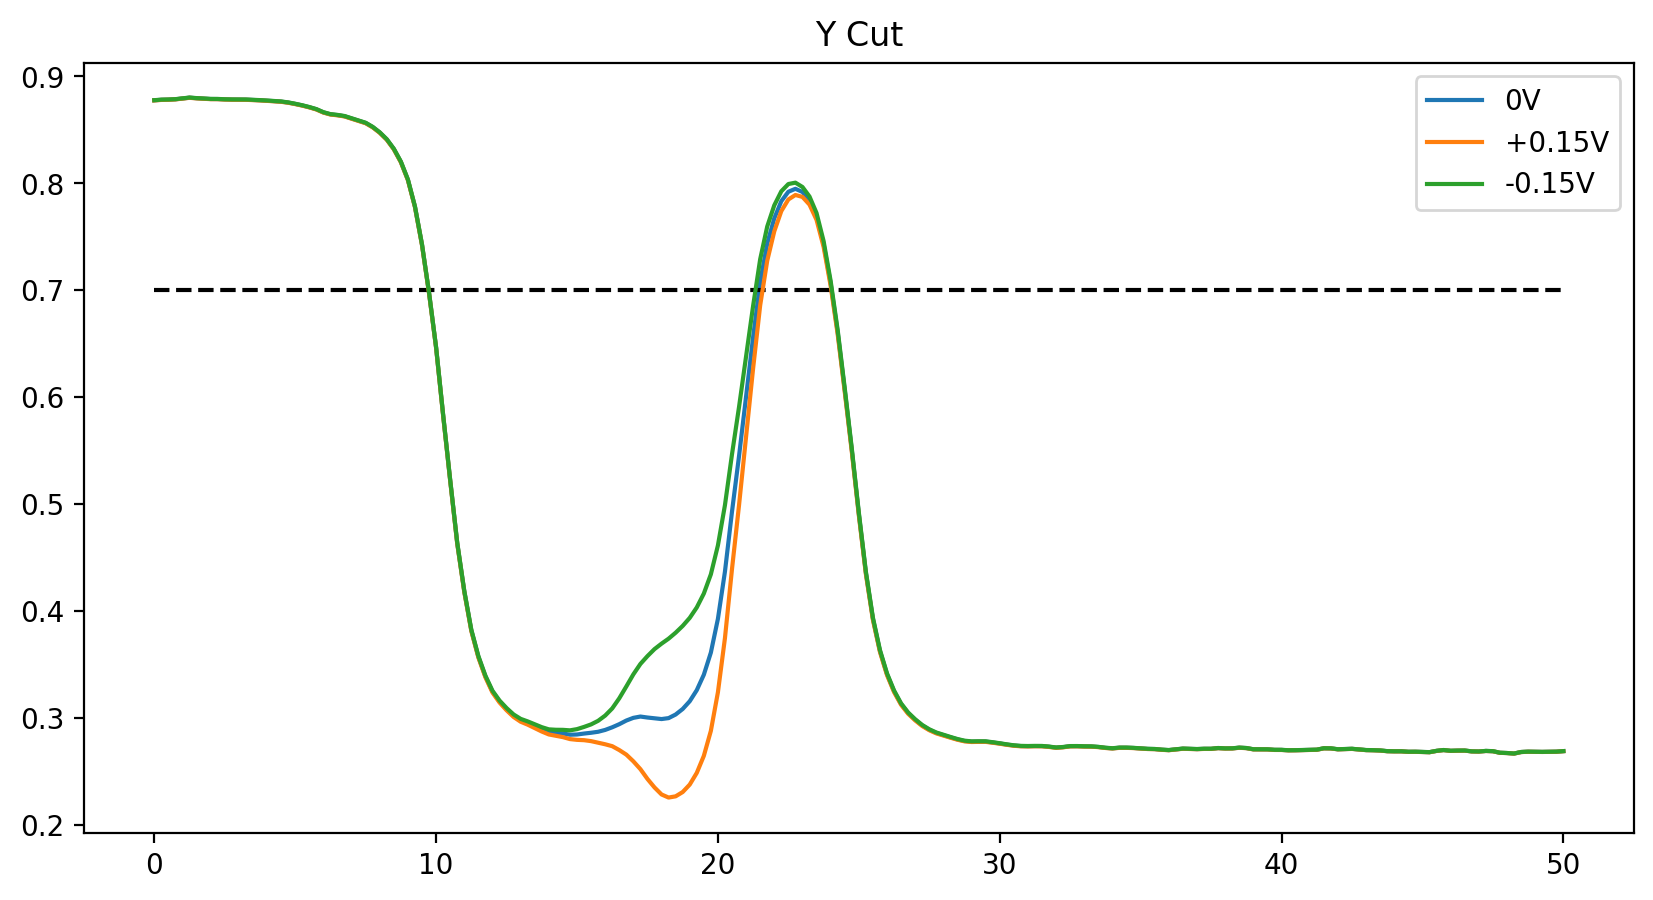

In [8]:
voltages = {
    'Barrier':-1,
    'Door1':-1,
    'Door2':-1,
    'Reservoir':0,
    'Sense':0,
    'ThinFilm':-1,
    'Top':-0.7,
    'Twiddle':0,
}
x,y,z = ph.potential(p,voltages)
xC = int(len(x)/2)

# Plot some line cuts along the center 
plt.figure(figsize=(10,5))
plt.title('Y Cut')
plt.plot(y,-z[xC,:],label='0V')
plt.hlines(-voltages['Top'],y.min(),y.max(),'k','--')

# Add a line, but with the twiddle at +0.15
voltages['Twiddle'] = .15
x,y,z = ph.potential(p,voltages)
plt.plot(y,-z[xC,:],label='+0.15V')

# Add a line, but with the twiddle at -0.15
voltages['Twiddle'] = -.15
x,y,z = ph.potential(p,voltages)
plt.plot(y,-z[xC,:],label='-0.15V')

plt.legend()
plt.show()


# Electron Counting

## Functions

In [9]:
import numpy as np

def generate_coords_deterministic(N, x0,y0,min_spacing=0):
    coords = []
    if min_spacing == 0:
        a = 0.1
    else:
        a = min_spacing
    r_max = a

    count = 0
    while count < N:
        coords.clear()
        r_max += a * 0.5  
        n_rings = int(r_max / a) + 1
        for i in range(-n_rings, n_rings + 1):
            for j in range(-n_rings, n_rings + 1):
                x = a * (i + 0.5 * j)
                y = a * (np.sqrt(3)/2) * j
                r = np.sqrt(x**2 + y**2)
                if r <= r_max:
                    coords.append((x0 + x, y0 + y))
                    if len(coords) >= N:
                        break
            if len(coords) >= N:
                break
        count = len(coords)

    return np.array(coords[:N])

def get_min_energy_forcemethod(fm,n_electrons: int=10,n_timesteps = 20_000,dt = 1e-13,gamma = -.01,init_coords=None,returnAll = False):
    gamma = gamma * me / dt # This is the damping parameter. 
    if init_coords is None:
        initial_condition = generate_coords_deterministic(int(N),0,0,0.15).flatten()*1e-6
    else:
        initial_condition = init_coords
    r = np.zeros((2 * n_electrons, n_timesteps+2))

    r[:, 0] = initial_condition
    r[:, 1] = initial_condition

    for k in range(2, n_timesteps+2):
        prefactor = 1 / (me / dt ** 2 - gamma / dt)
        F = - qe * fm.grad_total(r[:, k-1])
        r[:, k] = prefactor * (F - r[:, k-1] * (-2 * me / dt ** 2 + gamma / dt) - r[:, k-2] * me / dt ** 2)
    if returnAll:
        electron_positions = r
    else:
        electron_positions = r[:, -1]
    return electron_positions

## Solve Postions

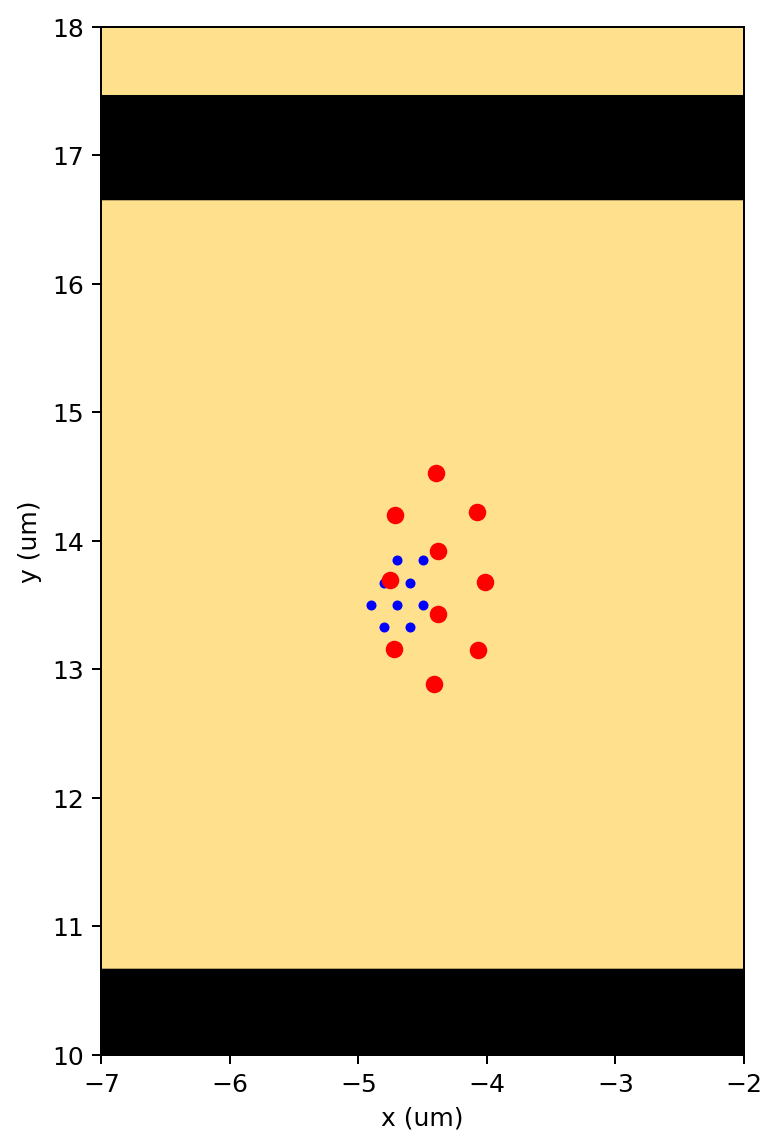

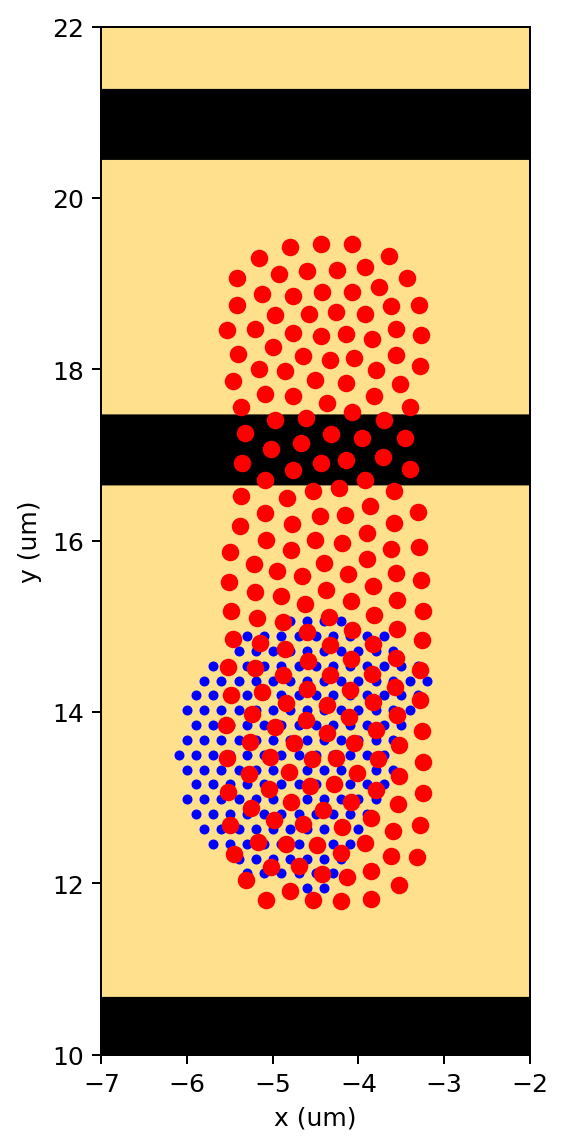

In [35]:
#just sense
voltages = {
    'Barrier':-1,
    'Door1':-1,
    'Door2':-1,
    'Reservoir':0,
    'Sense':0,
    'ThinFilm':-1,
    'Top':-1,
    'Twiddle':-1,
}

N = 10
min_spacing = 0.2
x0,y0 = -4.5,13.5     # where the electrons will be placed initially

x,y,z = ph.potential(p,voltages)
fm = FullModel(ph.phi, voltages, **options)

init_coords = generate_coords_deterministic(int(N),x0,y0,min_spacing).flatten()*1e-6
final_coords = get_min_energy_forcemethod(fm,N,n_timesteps = 2000,init_coords=init_coords)


device.quickplot(plot_config)
plt.xlim(-7,-2) # zoom in
plt.ylim(10,18)  # zoom in
# plt.xlim(-15,10)
# plt.ylim(-5,55)
for xi,yi in zip(init_coords[0::2],init_coords[1::2]):
    plt.plot(xi*1e6,yi*1e6,'b.')
for xi,yi in zip(final_coords[0::2],final_coords[1::2]):
    plt.plot(xi*1e6,yi*1e6,'ro')
plt.ylabel("y (um)")
plt.xlabel("x (um)")
plt.show()


## Twiddle and Sense
voltages = {
    'Barrier':-1,
    'Door1':-1,
    'Door2':-1,
    'Reservoir':0,
    'Sense':0,
    'ThinFilm':-1,
    'Top':-1,
    'Twiddle':0,
}

N = 200
min_spacing = 0.2
x0,y0 = -4.5,13.5     # where the electrons will be placed initially

x,y,z = ph.potential(p,voltages)
fm = FullModel(ph.phi, voltages, **options)

init_coords = generate_coords_deterministic(int(N),x0,y0,min_spacing).flatten()*1e-6
final_coords = get_min_energy_forcemethod(fm,N,n_timesteps = 2000,init_coords=init_coords)


device.quickplot(plot_config)
plt.xlim(-7,-2) # zoom in
plt.ylim(10,22)  # zoom in
# plt.xlim(-15,10)
# plt.ylim(-5,55)
for xi,yi in zip(init_coords[0::2],init_coords[1::2]):
    plt.plot(xi*1e6,yi*1e6,'b.')
for xi,yi in zip(final_coords[0::2],final_coords[1::2]):
    plt.plot(xi*1e6,yi*1e6,'ro')
plt.ylabel("y (um)")
plt.xlabel("x (um)")
plt.show()

Blue dots are the initial electron positions, and red dots are their positions given the set voltages. So with electrons starting in sense, can see the spread into twiddle when they're both a 0V and the doors are up. 

# Solve Dynamic Postions

 ## Drive needed to capture entire signal in twiddle and sense. 

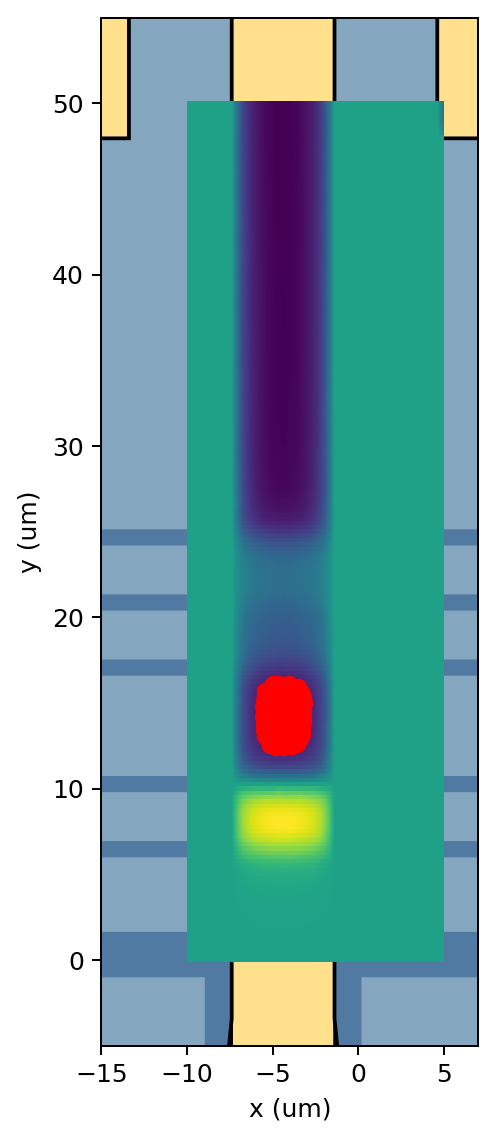

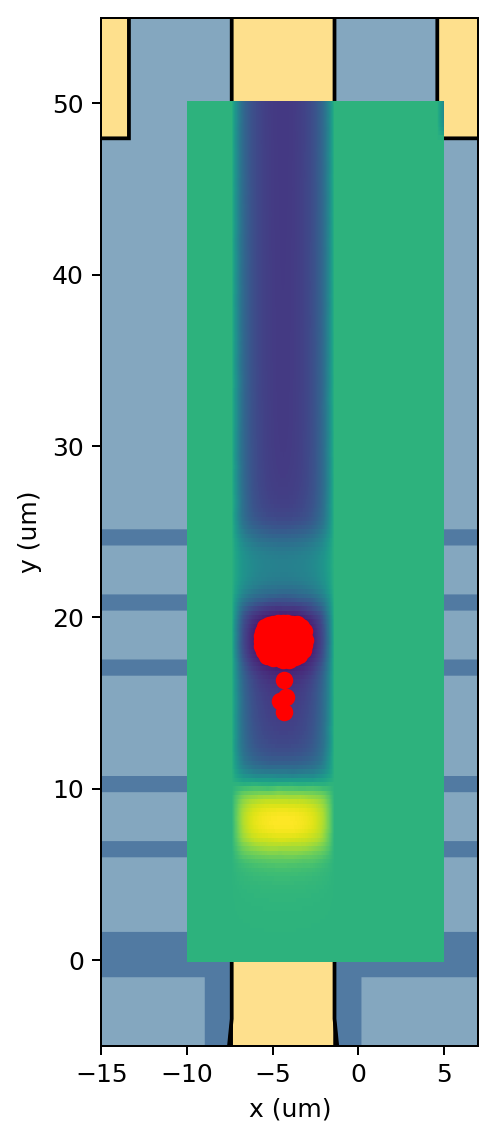

In [ ]:
voltages = {
    'Barrier':-1,
    'Door1':-0.7,
    'Door2':-2,
    'Reservoir':0,
    'Sense':0,
    'ThinFilm':-1,
    'Top':-1,
    'Twiddle':0,
}

N = 100
min_spacing = 0.2
x0,y0 = -5,14
vpp = 1

coords = generate_coords_deterministic(int(N),x0,y0,min_spacing).flatten()*1e-6
coords = get_min_energy_forcemethod(fm,N,n_timesteps = 2000,init_coords=coords)

for twiddle in [-vpp/2,vpp/2]:
    voltages['Twiddle'] = twiddle
    x,y,z = ph.potential(p,voltages)
    fm = FullModel(ph.phi, voltages, **options)
    coords = get_min_energy_forcemethod(fm,N,n_timesteps = 2000,init_coords=coords)
    
    device.quickplot(plot_config)
    plt.pcolormesh(x,y,-z.T)
    plt.xlim(-15,7)
    plt.ylim(-5,55)
    for xi,yi in zip(coords[0::2],coords[1::2]):
        plt.plot(xi*1e6,yi*1e6,'ro')
    plt.ylabel("y (um)")
    plt.xlabel("x (um)")
    plt.show()

## Sommer Tanner loading

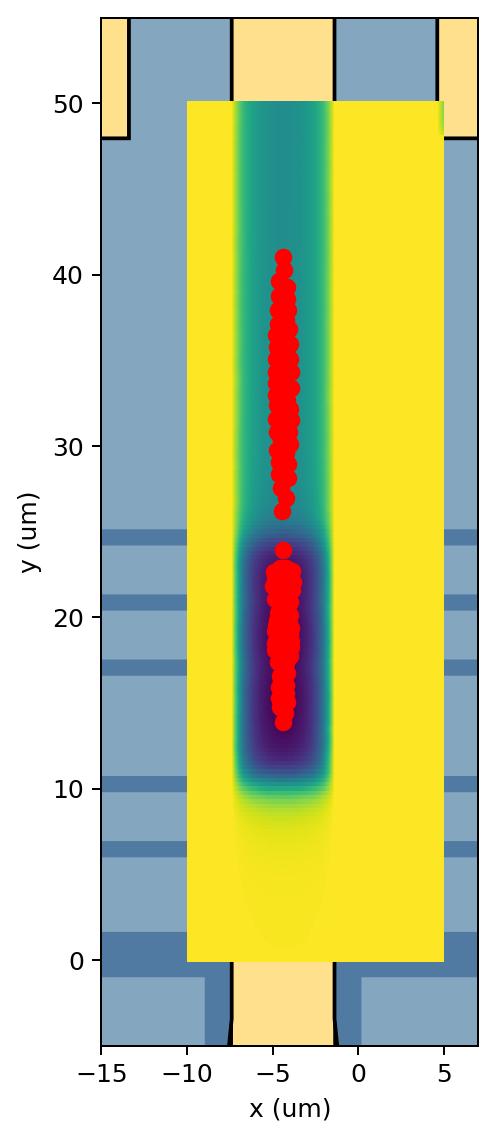

54

In [69]:
voltages = {
    'Barrier':-1,
    'Door1':0,
    'Door2':-1,
    'Reservoir':-0.5,
    'Sense':0,
    'ThinFilm':-1,
    'Top':-1,
    'Twiddle':0,
}

N = 100
min_spacing = 0.2
x0,y0 = -5,30
vpp = 2

coords = generate_coords_deterministic(int(N),x0,y0,min_spacing).flatten()*1e-6
coords = get_min_energy_forcemethod(fm,N,n_timesteps = 2000,init_coords=coords)

for twiddle in [0]:
    voltages['Twiddle'] = twiddle
    x,y,z = ph.potential(p,voltages)
    fm = FullModel(ph.phi, voltages, **options)
    coords = get_min_energy_forcemethod(fm,N,n_timesteps = 2000,init_coords=coords)
    
    device.quickplot(plot_config)
    plt.pcolormesh(x,y,-z.T)
    # plt.xlim(-9,0) # zoom in
    # plt.ylim(10,45) # zoom in
    plt.xlim(-15,7)
    plt.ylim(-5,55)
    for xi,yi in zip(coords[0::2],coords[1::2]):
        plt.plot(xi*1e6,yi*1e6,'ro')
    plt.ylabel("y (um)")
    plt.xlabel("x (um)")
    plt.show()

# Find number of electrons that make it from the reservoir: y range for area past reservoir gate = (25.5,10e-6)
sum(10e-6<i<25.5e-6 for i in coords[1::2])